<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2021/notebooks/lab_ch21_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'b46359d978b6550ab8cad23783c4ba65'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi.index.freq = 'MS'
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.
model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Inferred frequency None from passed values does not conform to passed frequency MS

**Identify the error**

The error is that the code fits ARIMA(2,0,1) on raw CPI, even though the ADF test shows the CPI series is non-stationary.  
Here, `d=0` means no differencing was applied, so the model is trying to use a non-stationary series in an ARIMA setup.

**Why it matters**

ARIMA models require the series to be stationary after differencing. Since raw CPI still has a unit root, using `d=0` violates this assumption. As a result, the model estimates can be unreliable, the fitted line can be misleading, and the forecasts may be poor.

**Correct**

Set the differencing order to **d=1** so the model works with the first-differenced CPI series like `ARIMA(cpi, order=(2,1,1))` This is more appropriate because CPI usually has a trend and needs differencing before ARIMA modeling.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


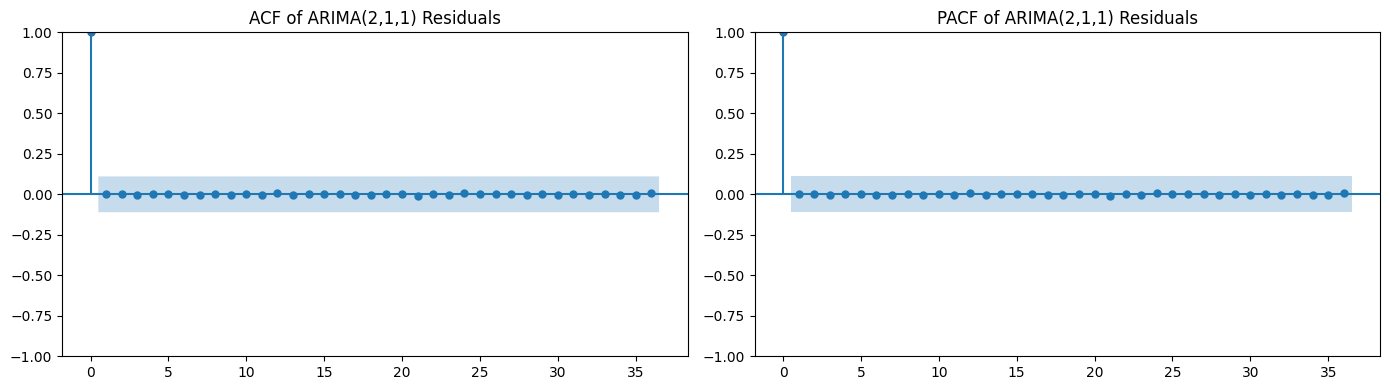

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: 0.0949
ACF at lag 24: 0.0782
If these are large (> 0.1), seasonality is leaking into residuals.


In [4]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

**Identify the error**

The error is that the code uses plain ARIMA(2,1,1) for monthly CPI and ignores seasonality. Even though setting `d=1` fixes the non-stationarity problem better than before, the model still does not include any seasonal terms.

**Why it matters**

CPI is monthly data, so it often has annual seasonal patterns, especially around lags 12, 24, and 36. If we use a non-seasonal ARIMA model, that seasonal structure is left in the residuals instead of being modeled directly. This means the model is still misspecified, and the forecasts may not be accurate. In this output, the residual autocorrelation at lag 12 is about 0.0949 and at lag 24 is about 0.0782. These are not extremely large, but they still suggest checking seasonal structure more carefully. For monthly CPI, it is better to use a seasonal model.

**Correct**

Replace plain ARIMA with SARIMA / SARIMAX, using a seasonal period of 12

`SARIMAX(cpi, order=(2,1,1), seasonal_order=(1,1,1,12))` This allows the model to capture both the regular dynamics and the yearly seasonal pattern in monthly CPI.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


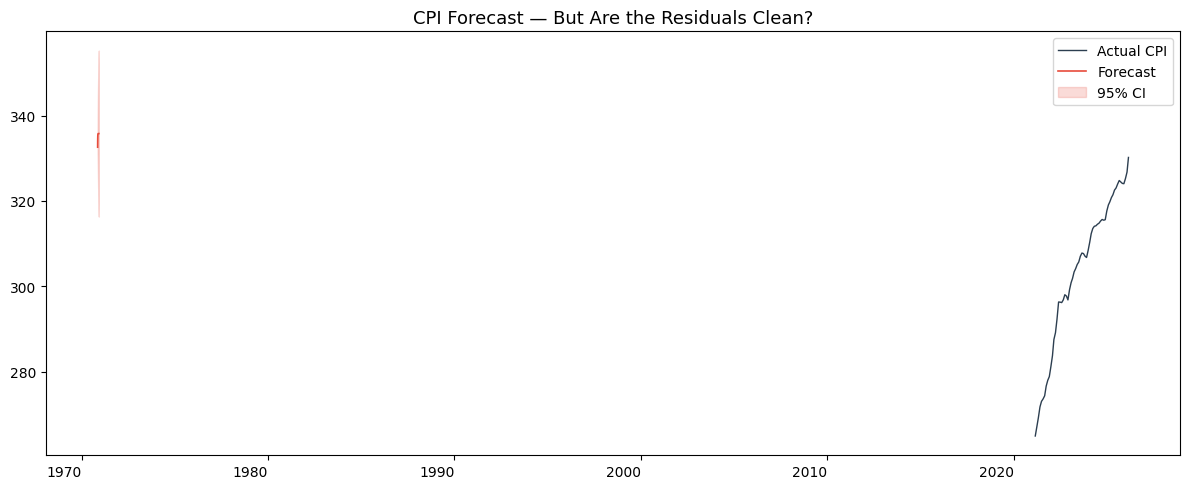

If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


In [5]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

**Identify the error**

The error is that the code goes directly to forecasting after fitting the model and skips residual diagnostics. In particular, it does not run the Ljung-Box test to check whether the residuals are autocorrelated.

**Why it matters**

A forecasting model should only be trusted if its residuals look like white noise. If the residuals still have autocorrelation, that means the model has not captured all the structure in the data and is still misspecified. This matters because the forecast and especially the 95% confidence interval may be misleading. The interval can be too narrow, which makes the forecast look more certain than it really is.

**Correct fix**

Before forecasting, run a Ljung-Box test on the residuals, for example at lags 12 and 24:

`acorr_ljungbox(residuals, lags=[12, 24], return_df=True)`

Then check that all p-values are greater than 0.05. If they are not, the model should be revised before using the forecast.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

In [6]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected ARIMA/SARIMA pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Step 1: Verify stationarity of differenced CPI
# cpi_diff = cpi.diff().dropna()
# adf_stat, adf_p, ... = adfuller(cpi_diff, ...)
# Assert p < 0.05
# Use log CPI to stabilize scale
cpi_log = np.log(cpi)
cpi_log = cpi_log.asfreq('MS')

cpi_diff = cpi_log.diff().dropna()

adf_stat, adf_p, _, _, _, _ = adfuller(cpi_diff, autolag='AIC')
print("ADF test on differenced log CPI:")
print(f"  Test statistic: {adf_stat:.4f}")
print(f"  P-value: {adf_p:.4f}")
print(f"  Conclusion: {'Stationary' if adf_p < 0.05 else 'NON-STATIONARY'}")

assert adf_p < 0.05, "Differenced log CPI is still non-stationary"

# Step 2: Fit SARIMA with seasonal order (P, D, Q, 12)
# Option A: manual SARIMAX(cpi, order=(p,1,q), seasonal_order=(P,1,Q,12))
# Option B: pm.auto_arima(cpi, seasonal=True, m=12)
model = SARIMAX(
    cpi_log,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print("\nSARIMA model fit complete.")
print(f"AIC: {result.aic:.2f}")
print(f"BIC: {result.bic:.2f}")


# Step 3: Ljung-Box diagnostic on residuals
# lb = acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)
# Assert all p-values > 0.05
residuals = result.resid.dropna()
lb = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)

print("\nLjung-Box test on residuals:")
print(lb)

# Step 4: Forecast (only if Ljung-Box passes)
if (lb["lb_pvalue"] > 0.05).all():
    print("\nResiduals look like white noise. Proceed to forecasting.")

    forecast = result.get_forecast(steps=24)
    ci = forecast.conf_int(alpha=0.05)

    print(f"24-month forecast range: {np.exp(ci.iloc[0, 0]):.1f} to {np.exp(ci.iloc[-1, 1]):.1f}")

else:
    print("\nWARNING: Residuals show autocorrelation. Model is misspecified.")
    print("Do not trust the forecast until the residual diagnostics pass.")

# VERIFICATION
# print('ADF p-value on diff(CPI):', adf_p)  # Should be < 0.05
# print('Ljung-Box p-values:', lb['lb_pvalue'].values)  # Should be > 0.05
# print('ACF at lag 12:', ...)  # Should be small (< 0.1)
acf_12 = pd.Series(residuals).autocorr(lag=12)
acf_24 = pd.Series(residuals).autocorr(lag=24)

print("\nVERIFICATION")
print("ADF p-value on diff(log CPI):", adf_p)
print("Ljung-Box p-values:", lb["lb_pvalue"].values)
print(f"ACF at lag 12: {acf_12:.4f}")
print(f"ACF at lag 24: {acf_24:.4f}")

ADF test on differenced log CPI:
  Test statistic: -3.3773
  P-value: 0.0118
  Conclusion: Stationary


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMA model fit complete.
AIC: -2529.76
BIC: -2507.78

Ljung-Box test on residuals:
      lb_stat     lb_pvalue
6    5.951134  4.286863e-01
12  63.888637  4.372411e-09
18  67.043030  1.420495e-07
24  67.649261  4.934805e-06

Do not trust the forecast until the residual diagnostics pass.

VERIFICATION
ADF p-value on diff(log CPI): 0.011758871683200651
Ljung-Box p-values: [4.28686279e-01 4.37241079e-09 1.42049482e-07 4.93480507e-06]
ACF at lag 12: -0.7924
ACF at lag 24: -0.8343


**Interpretation:**

The corrected pipeline fixed the first problem by differencing log CPI. The ADF test on the differenced series gives a p-value of 0.0118, which is below 0.05, so the series is stationary after differencing.Moreovoer, the pipeline also fixed the second problem by using a seasonal SARIMA model, SARIMA(2,1,1)(1,1,1,12), which accounts for monthly seasonality.

However, the Ljung-Box test shows that the residuals still have autocorrelation at seasonal lags. The p-values at lags 12, 18, and 24 are all far below 0.05, so we reject the null hypothesis that the residuals are white noise. This means the model is still misspecified, and the forecast should not be trusted yet. In this case, the residual autocorrelations at lags 12 and 24 are also large in magnitude, which suggests that important seasonal structure remains in the residuals. So, even though the pipeline is now correctly structured, the current SARIMA specification does not fully capture the data.

---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

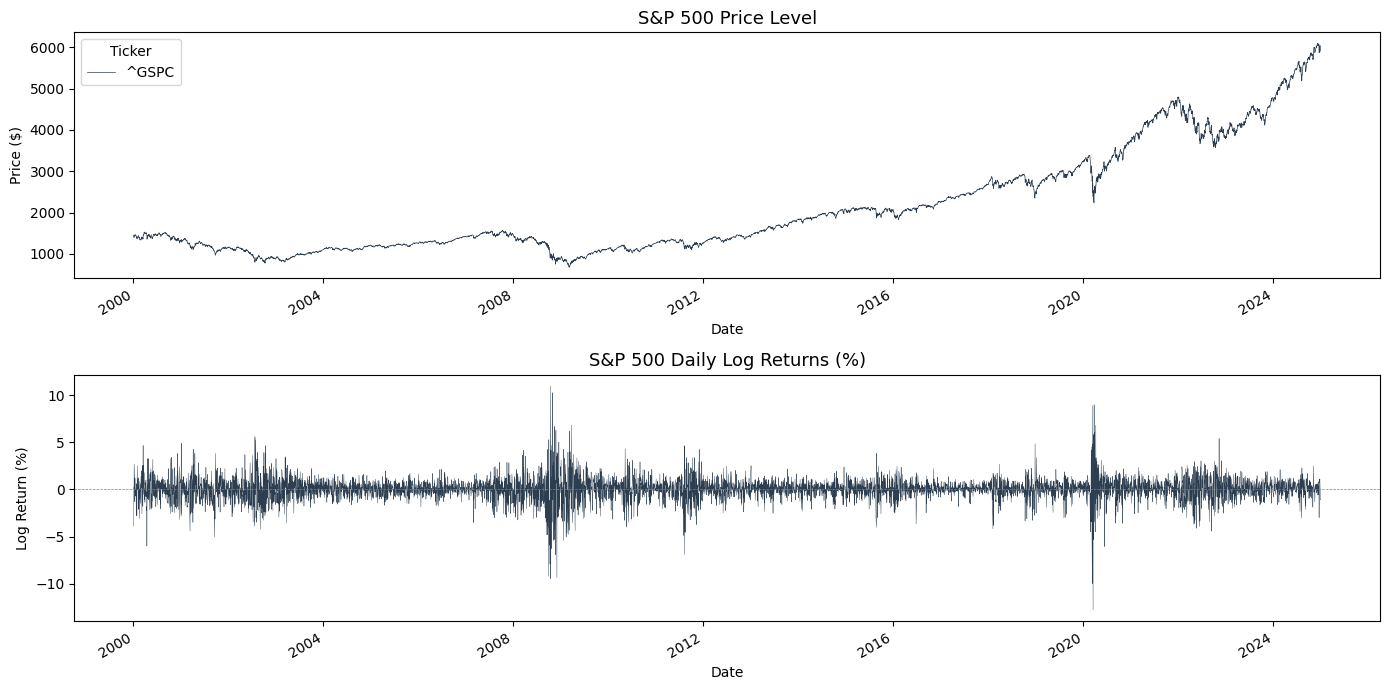

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [9]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# -----------------------------------------------------------

# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)
from arch import arch_model

garch = arch_model(returns,
                   vol='Garch',
                   p=1,
                   q=1,
                   mean='AR',
                   lags=1)
garch_result = garch.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.007
Mean Model:                        AR   Adj. R-squared:                  0.006
Vol Model:                      GARCH   Log-Likelihood:               -8644.25
Distribution:                  Normal   AIC:                           17298.5
Method:            Maximum Likelihood   BIC:                           17332.2
                                        No. Observations:                 6286
Date:                Fri, Apr 17 2026   Df Residuals:                     6284
Time:                        01:03:00   Df Model:                            2
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const             0.0654  1.051e-02      6.

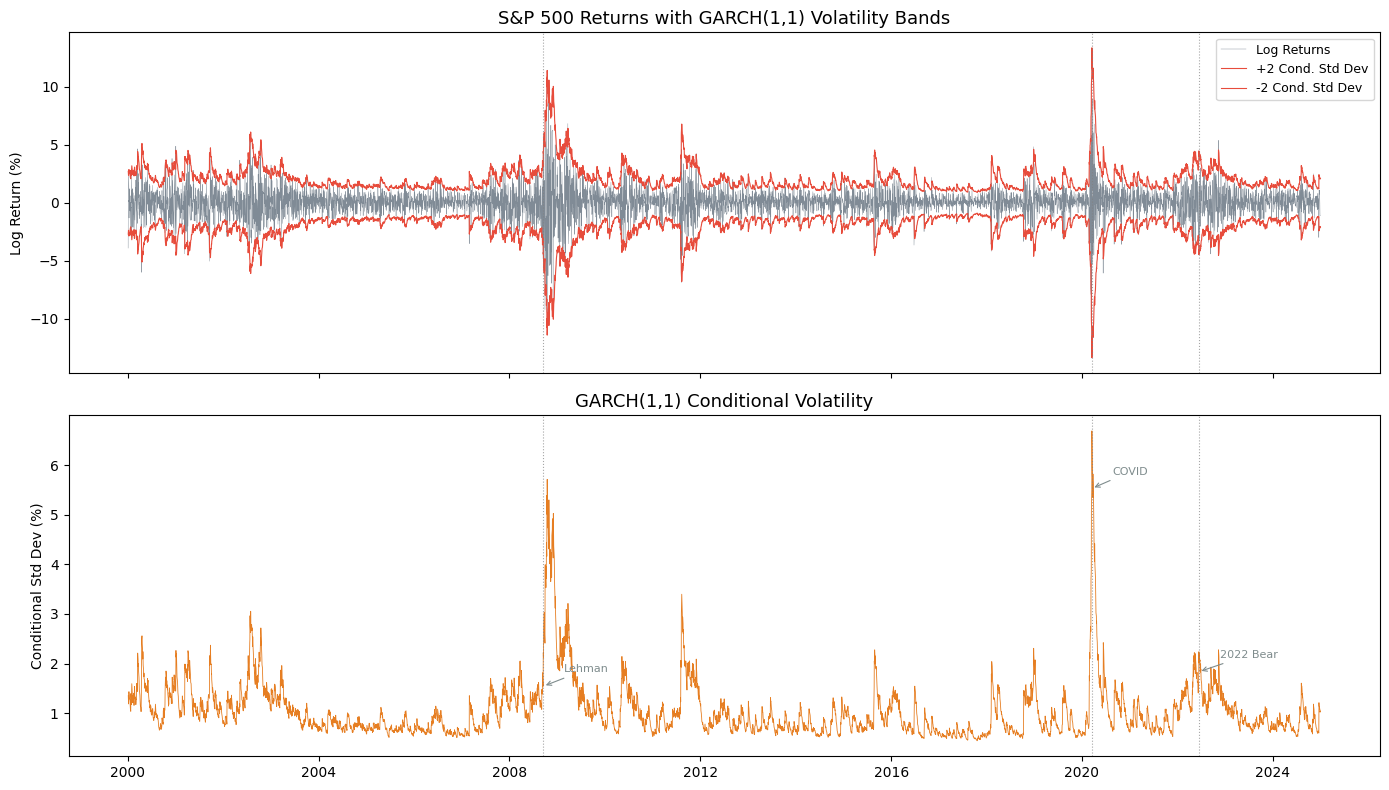

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1677%
Max conditional volatility: 6.6873% on 2020-03-17


In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

**Interpretation:**

The high beta (0.8631) means volatility is very persistent, so a spike in market uncertainty, such as during COVID-19 in 2020, takes a long time to fade. Because alpha + beta = 0.9829 < 1, the conditional variance is still mean-reverting, so volatility does not grow forever. The long-run unconditional variance is given by:`omega / (1 - alpha - beta)` This means the model allows volatility to spike in the short run but eventually return toward its long-run level.

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [11]:
# -----------------------------------------------------------
# YOUR TASK — Write forecast_evaluation.py
# Implement compute_mase() and backtest_expanding_window()
# -----------------------------------------------------------

# %%writefile forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: Guanyu Qu
Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit


def compute_mase(actual: np.ndarray, predicted: np.ndarray,
                 train: np.ndarray, m: int = 12) -> float:
    """Compute Mean Absolute Scaled Error.

    Args:
        actual: Array of actual out-of-sample values.
        predicted: Array of predicted values (same length as actual).
        train: Array of in-sample training values.
        m: Seasonal period for naive benchmark (12 for monthly).

    Returns:
        MASE value. < 1 means model beats seasonal naive.
    """
    # YOUR IMPLEMENTATION HERE
    # Hint:
    # mae_forecast = np.mean(np.abs(actual - forecast))
    # naive_errors = insample[m:] - insample[:-m]
    # mae_naive = np.mean(np.abs(naive_errors))
    # return mae_forecast / mae_naive
    forecast_mae = np.abs(actual - predicted).mean()
    naive_mae = np.abs(train[m:] - train[:-m]).mean()
    return forecast_mae / naive_mae


def backtest_expanding_window(series: pd.Series, model_fn,
                               n_splits: int = 5) -> list:
    """Expanding-window backtest for time series models.

    Args:
        series: Full time series (pandas Series with DatetimeIndex).
        model_fn: Callable that takes (train_series) and returns
                  predicted values for h steps ahead.
        n_splits: Number of expanding windows.

    Returns:
        List of MASE scores, one per split.
    """
    # YOUR IMPLEMENTATION HERE
    # Hint: loop from min_train to len(series)-horizon, stepping by step
    # For each origin:
    #   train = series[:origin]
    #   actual = series[origin:origin+horizon].values
    #   forecast = model_fn(train)
    #   compute errors and MASE

    tscv = TimeSeriesSplit(n_splits=n_splits)
    mase_scores = []

    for train_idx, test_idx in tscv.split(series):
        train = series.iloc[train_idx]
        test = series.iloc[test_idx]
        h = len(test)

        predicted = model_fn(train, h)
        mase = compute_mase(test.values, predicted, train.values, m=12)
        mase_scores.append(mase)

    return mase_scores


# --- Quick self-test ---
if __name__ == '__main__':
    # Add your own test calls here
    train = np.sin(np.linspace(0, 8*np.pi, 120))  # 10 years of synthetic monthly data
    actual = np.sin(np.linspace(8*np.pi, 9*np.pi, 12))
    predicted = actual + np.random.normal(0, 0.1, 12)

    mase = compute_mase(actual, predicted, train, m=12)
    print(f"Test MASE: {mase:.3f}")

Test MASE: 0.053


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

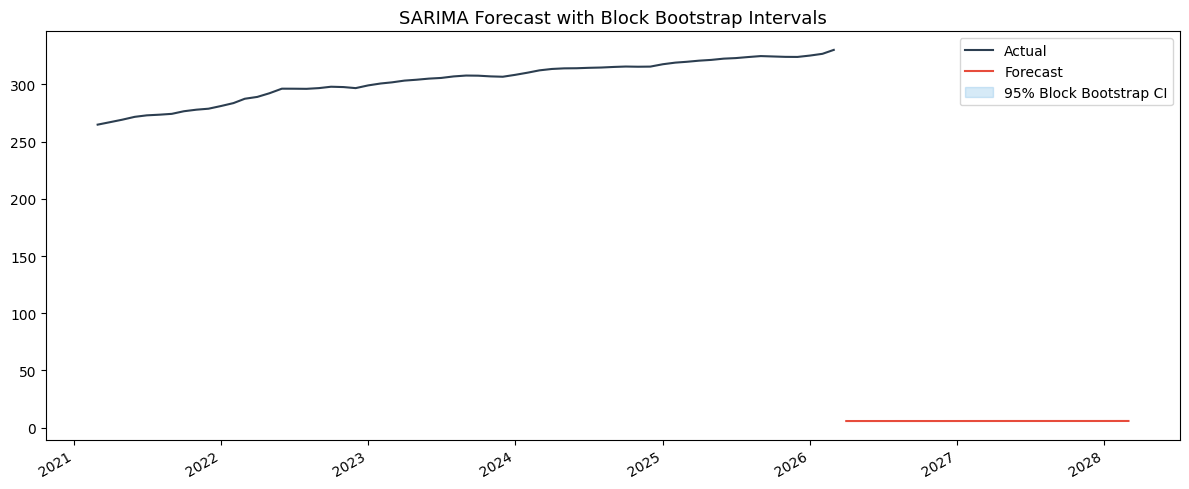

In [12]:
# -----------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# Fill in the blanks (___) to complete the implementation
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05
):
    """Generate block-bootstrap forecast intervals.

    Args:
        model_result: Fitted SARIMAX result object
        horizon: Number of steps to forecast
        n_bootstrap: Number of bootstrap replications
        block_size: Block length for moving block bootstrap
        alpha: Significance level (0.05 = 95% CI)

    Returns:
        dict with 'mean', 'lower', 'upper', 'paths' keys
    """
    # Get the point forecast
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    # Extract residuals from the fitted model
    residuals = model_result.resid.values
    n_resid = len(residuals)

    # Store bootstrap forecast paths
    boot_paths = np.zeros((n_bootstrap, horizon))  # FILL IN: what is the second dimension?

    for b in range(n_bootstrap):
        # Moving block bootstrap on residuals
        boot_resid = np.zeros(horizon)
        idx = 0
        while idx < horizon:  # FILL IN: loop until we have enough residuals
            start = np.random.randint(0, n_resid - block_size + 1)  # FILL IN: valid block start range
            block = residuals[start:start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Bootstrap path = point forecast + resampled residuals
        boot_paths[b, :] = forecast_mean + boot_resid  # FILL IN: combine forecast and residuals

    # Percentile-based confidence intervals
    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=0)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)

    return {
        'mean': forecast_mean,
        'lower': lower,
        'upper': upper,
        'paths': boot_paths
    }


# Usage (uncomment after fixing Part 2):
boot_ci = block_bootstrap_forecast(result, horizon=24, n_bootstrap=500)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual', color='#2c3e50')
forecast_idx = pd.date_range(cpi.index[-1], periods=25, freq='MS')[1:]
ax.plot(forecast_idx, boot_ci['mean'], color='#e74c3c', label='Forecast')
ax.fill_between(forecast_idx, boot_ci['lower'], boot_ci['upper'],alpha=0.2, color='#3498db', label='95% Block Bootstrap CI')
ax.set_title('SARIMA Forecast with Block Bootstrap Intervals', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Comparison and Interpretation:**

Block bootstrap intervals are usually wider than parametric SARIMA intervals, especially for longer forecasts. This is because bootstrap methods capture more sources of uncertainty, including non-normal residuals. In contrast, parametric intervals assume residuals follow a normal distribution, which is often unrealistic for financial and macroeconomic data.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.